In [2]:
import torch
from torch import nn # nn contains all of PyTorch's buidling blocks for neural networks
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [3]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference) ",
    5: "saving and loading model",
    6: "putting it all together"
}

what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference) ',
 5: 'saving and loading model',
 6: 'putting it all together'}

# 1. data (preparing and loading)

Data can be almost anything.. in machine learning.

* excel speadsheet
* images of any king
* videos
* Audio like songs or podcast
* DNA
* Text


Machine learning is a game of two parts

1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation


To showcase this, let's create some known data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**.


In [4]:
# create known parameters
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02

# X том үсгээр эхэлсэн байгаа. Энэ нь tensor and matrix илэрхийлдэг
# y жижиг үсгээр эхэлсэг байгаа. энэ нь vector илэрхийлдэг
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
len(X), len(y)

(50, 50)

# Splitting data into trainig and testing sets


In [6]:
# create a train/test split
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_yest = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_yest)

(40, 40, 10, 10)

In [7]:
def plot_predictions(train_data=X_train,train_labels=y_train,test_data = X_test, test_labels = y_yest, predictions=None):
    # Plots training data, test data and compares predictions
    plt.figure(figsize=(10, 7))

    # plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label='Training data')

    # plot test data in green
    plt.scatter(test_data, test_labels, c="r", s=4, label='Testing data')

    # are there predictions?
    if predictions is not None:
        # plot  the predictions if they exist
        plt.scatter(test_data, predictions, c="g", s=4, label='Predictions')

    # show the legend
    plt.legend(prop={"size": 14})
    

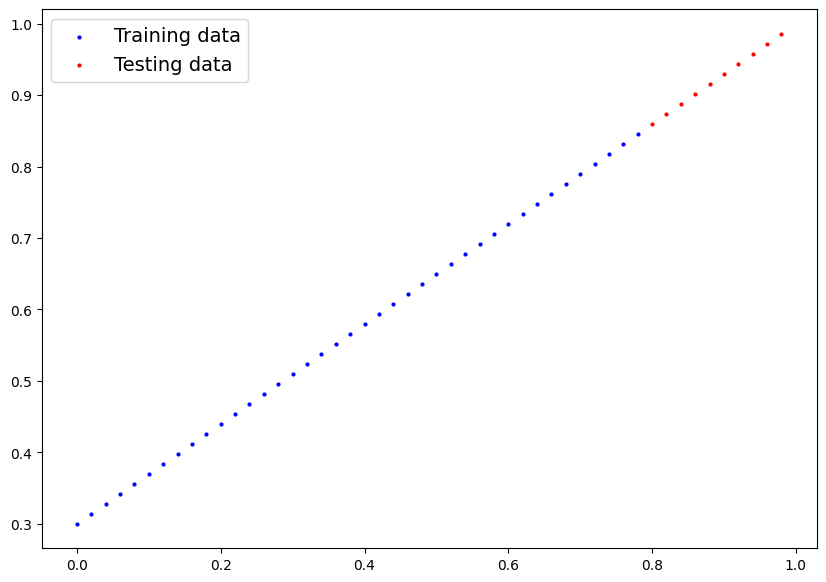

In [8]:
plot_predictions()

# build model

In [9]:
# create linear regression model class

# nn.Module -> almost everything in PyTorch inherits from nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
    # x is input data
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias # this is the linear regression formula


In [10]:
torch.manual_seed(42) # remove this code and then execute it 
torch.randn(1)

tensor([0.3367])

# PyTorch model building essentials

* torch.nn - contains all of the buidligs for computational graphs(another word for neural netwrok can be considered a computtational graph)
* torch.nn.Parameter -  What parameters should our model try an learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module _ The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in PyTorch live, they wll help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

# checking the contents of our PyTorch model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using. parameters().

In [11]:
# creare a random seed
torch.manual_seed(42)

# create an instance of the model (thsi is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Making prediction using `torch.inference_mode()`

To check our model's predictivce power, let's see how ell it predicts `y_test` based on `X_test`

when we pass data through our mode, it's going to run it through the `forward()` method.

In [13]:
X_test, y_yest

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [14]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [15]:
# make predictions wiht model
with torch.inference_mode():
    y_preds = model_0(X_test)

# you can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

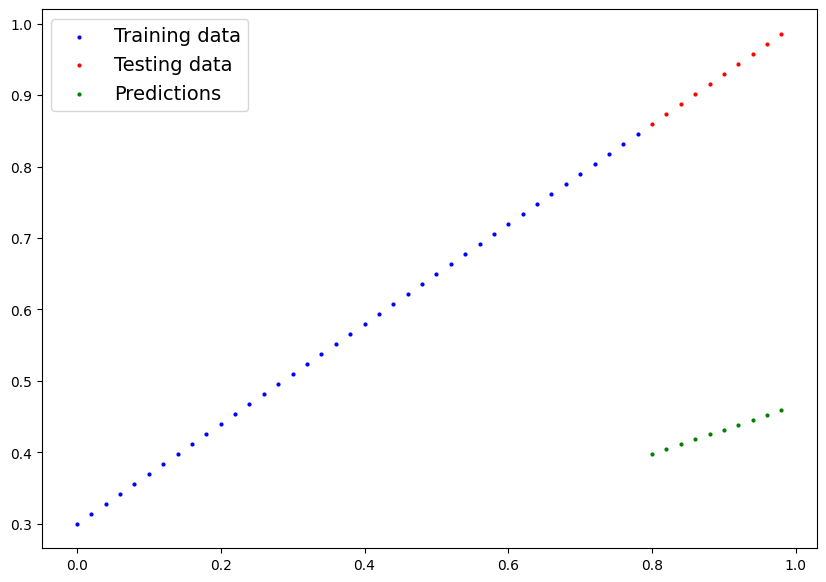

In [16]:
plot_predictions(predictions=y_preds)

# Train model

The whole idea of training is for a model to move from somve unknown parameters(thses may be random) to some known parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your models predictions are is to usea loss function.


* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function

Things we need to train:

*  **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better
*  **Optimizer:** Takes into account the loss of a model and adjust the model's parameters(e.g weight & bias in our case ) to improve the loss function.

and specifically for PyTorch, we need:
* A training loop
* A testing loop

In [17]:
# check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Loss function

**Mean absolute erro(MAE) = Repeat fot all and take the mean

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png" alt="Alt text" width="700" height="400">


In [18]:
# setup a loss function
loss_fn = nn.L1Loss()

# setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr=learning rate = possible the most important hyperparameter you can set

In [19]:
loss_fn

L1Loss()

# Building a training loop (and a testing loop) in PyTorch
a couple of things we need in a traininn loop:

0. Loop through the data
1. Forward pass (thi involves data moving through our model's `forward()` function ) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labes)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model woth repsect to the loss
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [20]:
model_0.eval().parameters
with torch.inference_mode():
    list(model_0.parameters())

In [21]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [22]:
# Training
# An epoch is one loop through the data...
epochs = 200

# track different values
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. perform backpropagation on the loss with respect tp the parameters of the model
    loss.backward()

    # 5. step the optimizer (perform gradient descent)
    optimizer.step()    # by default how the optimizer changes will acculumate the loop so.. we have to zero them above in step 3 for the next iteration of the loop
    
    # Testing
    model_0.eval() # turns off different settings in the model not needed for evaluatuin/testing (dropout/ batch norm layers)
    with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # 2. calculate the loss
        test_loss = loss_fn(test_pred, y_yest)

    # print out what's happening
    if epoch % 10 ==0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict([('weights', tensor([0.5116])), ('bias', tensor([0.3788

In [23]:
np.array(torch.tensor(loss_values).numpy()), test_loss_values

C:\Users\tumur\AppData\Local\Temp\ipykernel_18348\1077254813.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  np.array(torch.tensor(loss_values).numpy()), test_loss_values


(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

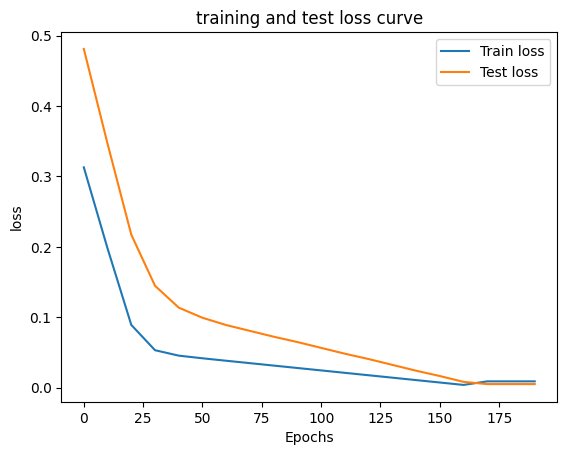

In [24]:
# plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("training and test loss curve")
plt.ylabel("loss")
plt.xlabel("Epochs")
plt.legend()

In [25]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [27]:
weight, bias

(0.7, 0.3)

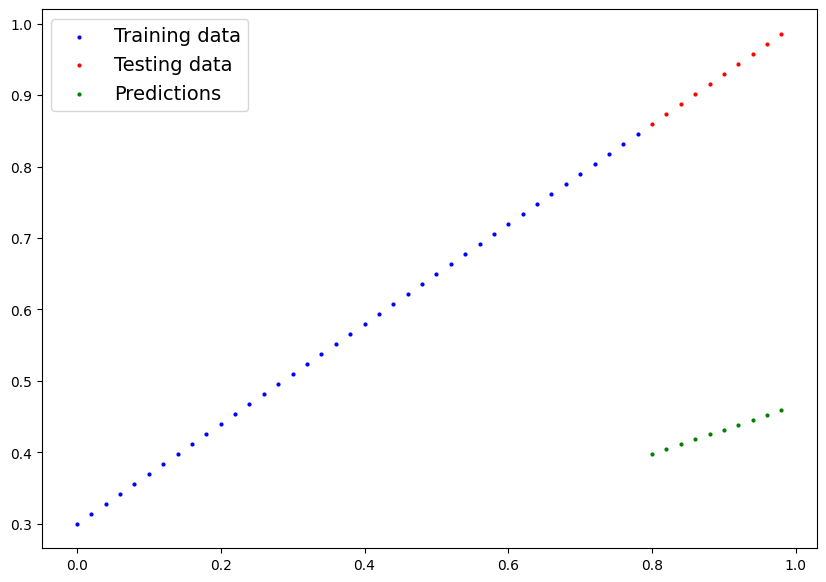

In [28]:
plot_predictions(predictions=y_preds)

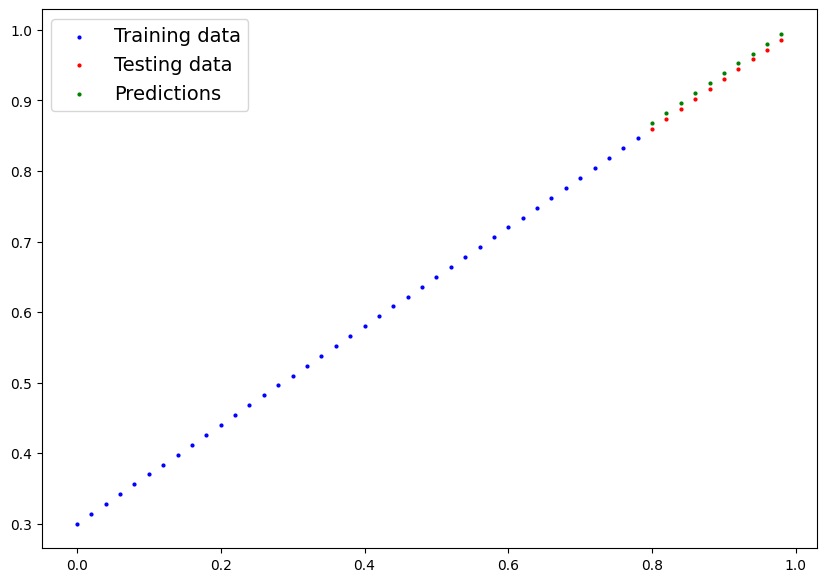

In [29]:
plot_predictions(predictions=y_preds_new)

# Saving a model in PyTorch

There a three main methods you should about for saving and loading models in PyTorch.
1. torch.save() - allows you a PyTorch object in Python's pickle format
2. torch.load() - allows you load a saved PyTorch object
3. torch.nn.Module.load_state_dict() - this allows to load a model's saved state dictionary

In [30]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [31]:
model_0

LinearRegressionModel()

In [32]:
# Saving our PyTorch model
# 1. create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to : models\01_pytorch_workflow_model_0.pth


# Loading a PyTorch model
Since we saved our model's `state.dict()` rather the entire model, we'll create a new instance of our model class and load the save `state.dict()` into that

In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [34]:
# To load in a saved_dict we have to instantiate a new instance of your model class
loaded_model_0 = LinearRegressionModel()

# Load the save state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [35]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])